## Forest patch counts (baseline -- no action roads)

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path

RESULTS_DIR = Path("../model/results/impact-assessment/batch15")
PATCH_DIR   = Path("../data/output/forest-patch-detection")
ADMIN0_FP   = Path("../data/input/cmr_admin_boundaries_humdata/cmr_admin0.shp")

cmr0_wgs = gpd.read_file(ADMIN0_FP).to_crs("EPSG:4326")

print("Setup complete.")


Setup complete.


Helpers ready: patch_size_distribution(), patch_size_raster()
Total patches: 26,176  |  Total forest area: 33,270,182 ha



,Size class,Patch count,Total area (ha),% of patches,% of forest area
0,"> 1,000,000 ha",9,"25,628,368.1",0.03%,77.03%
1,"100,000 – 1,000,000 ha",15,"5,827,210.5",0.06%,17.51%
2,"10,000 – 100,000 ha",30,"978,949.0",0.11%,2.94%
3,"1,000 – 10,000 ha",118,"334,296.9",0.45%,1.00%
4,"100 – 1,000 ha",898,"222,936.0",3.43%,0.67%
5,10 – 100 ha,"7,708","205,942.6",29.45%,0.62%
6,1 – 10 ha,"17,391","72,474.1",66.44%,0.22%
7,< 1 ha,7,4.8,0.03%,0.00%


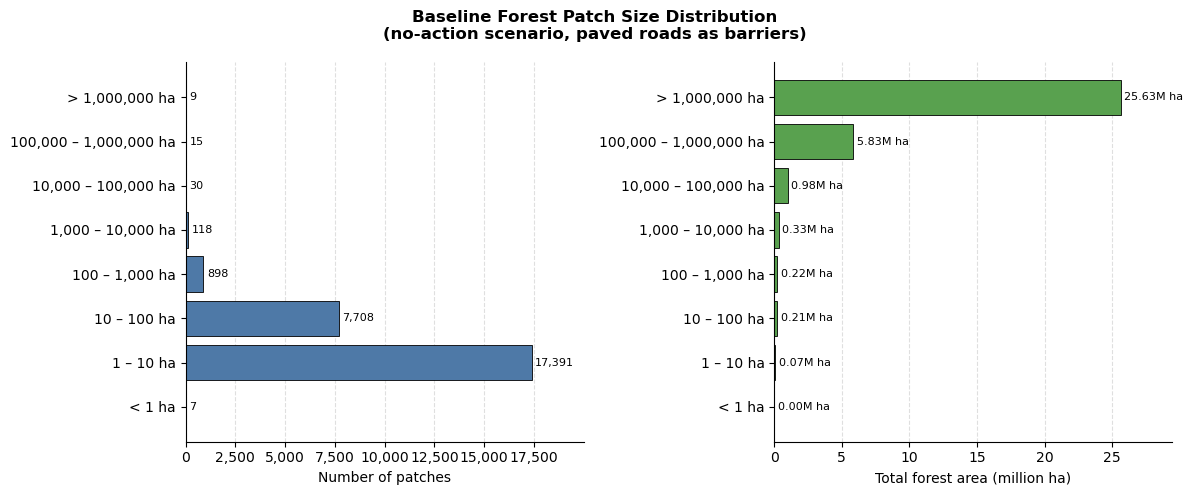

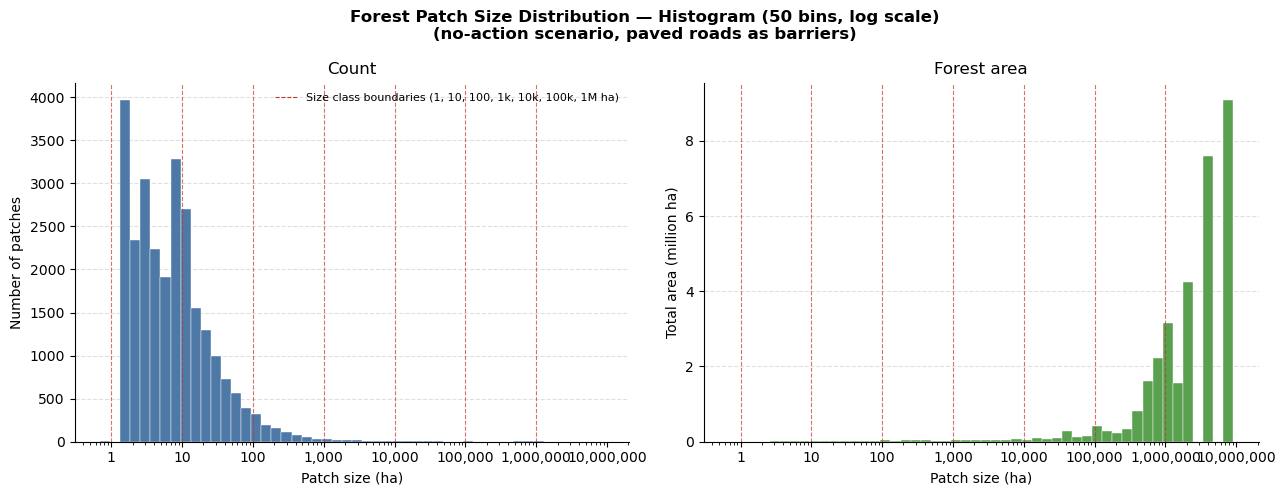

In [2]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display as ipy_display

SIZE_BINS = [
    ("> 1,000,000 ha",        lambda h: h > 1_000_000),
    ("100,000 – 1,000,000 ha",lambda h: (h >= 100_000) & (h <= 1_000_000)),
    ("10,000 – 100,000 ha",   lambda h: (h >= 10_000)  & (h <  100_000)),
    ("1,000 – 10,000 ha",     lambda h: (h >= 1_000)   & (h <  10_000)),
    ("100 – 1,000 ha",        lambda h: (h >= 100)     & (h <  1_000)),
    ("10 – 100 ha",           lambda h: (h >= 10)      & (h <  100)),
    ("1 – 10 ha",             lambda h: (h >= 1)       & (h <  10)),
    ("< 1 ha",                lambda h:  h < 1),
]


def patch_size_distribution(tif_path):
    with rasterio.open(tif_path) as src:
        arr   = src.read(1)
        tf    = src.transform
        lat_c = tf.f + (src.height / 2) * tf.e
        pix_w = abs(tf.a) * 111_320 * np.cos(np.radians(lat_c))
        pix_h = abs(tf.e) * 111_320
        pixel_ha = (pix_w * pix_h) / 10_000

    _, px_counts = np.unique(arr[arr > 0], return_counts=True)
    patch_ha = px_counts * pixel_ha

    rows = []
    for label, condition in SIZE_BINS:
        mask = condition(patch_ha)
        n    = int(mask.sum())
        area = float(patch_ha[mask].sum())
        rows.append({
            "Size class":        label,
            "Patch count":       n,
            "Total area (ha)":   round(area, 1),
            "% of patches":      round(100 * n    / len(patch_ha),   2),
            "% of forest area":  round(100 * area / patch_ha.sum(),  2),
        })

    return pd.DataFrame(rows), patch_ha


def patch_size_raster(tif_path):
    with rasterio.open(tif_path) as src:
        arr    = src.read(1)
        tf     = src.transform
        lat_c  = tf.f + (src.height / 2) * tf.e
        pix_w  = abs(tf.a) * 111_320 * np.cos(np.radians(lat_c))
        pix_h  = abs(tf.e) * 111_320
        pixel_ha = (pix_w * pix_h) / 10_000
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    patch_ids, px_counts = np.unique(arr[arr > 0], return_counts=True)
    patch_areas = (px_counts * pixel_ha).astype(np.float32)

    id_to_area = np.zeros(int(patch_ids.max()) + 1, dtype=np.float32)
    id_to_area[patch_ids] = patch_areas

    size_arr = np.zeros(arr.shape, dtype=np.float32)
    fg = arr > 0
    size_arr[fg] = id_to_area[arr[fg]]

    return size_arr, tf, extent


print("Helpers ready: patch_size_distribution(), patch_size_raster()")

# ── Run distribution on baseline no-action TIF ────────────────────────────────
_BASELINE_TIF = Path("../data/output/forest-patch-detection") / \
                "no_action__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.tif"

size_df, patch_ha = patch_size_distribution(_BASELINE_TIF)
print(f"Total patches: {len(patch_ha):,}  |  Total forest area: {patch_ha.sum():,.0f} ha\n")

ipy_display(
    size_df.style
    .set_caption("Baseline forest patch size distribution (no-action, paved roads as barriers)")
    .format({
        "Patch count":      "{:,}",
        "Total area (ha)":  "{:,.1f}",
        "% of patches":     "{:.2f}%",
        "% of forest area": "{:.2f}%",
    })
    .bar(subset=["Patch count"],     color="#aec6e8", vmin=0)
    .bar(subset=["Total area (ha)"], color="#c8e6c9", vmin=0)
)

# ── Summary bar chart ─────────────────────────────────────────────────────────
labels = size_df["Size class"].tolist()
counts = size_df["Patch count"].tolist()
areas  = size_df["Total area (ha)"].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Baseline Forest Patch Size Distribution\n(no-action scenario, paved roads as barriers)",
    fontsize=12, fontweight="bold",
)

for ax, vals, xlabel, color, fmt_fn in [
    (ax1, counts, "Number of patches",          "#4e79a7", lambda v: f"{v:,}"),
    (ax2, [v / 1e6 for v in areas], "Total forest area (million ha)", "#59a14f",
     lambda v: f"{v:.2f}M ha"),
]:
    ax.barh(labels[::-1], vals[::-1], color=color, edgecolor="black", linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, max(vals) * 1.15)
    for i, v in enumerate(vals[::-1]):
        ax.text(v + max(vals) * 0.01, i, fmt_fn(v), va="center", fontsize=8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_baseline_patch_size_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Continuous histogram (50 log-spaced bins) ─────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Forest Patch Size Distribution — Histogram (50 bins, log scale)\n"
    "(no-action scenario, paved roads as barriers)",
    fontsize=12, fontweight="bold",
)

log_bins = np.logspace(np.log10(patch_ha.min()), np.log10(patch_ha.max()), 51)

ax_l.hist(patch_ha, bins=log_bins, color="#4e79a7", edgecolor="white", linewidth=0.3)
ax_l.set_xscale("log")
ax_l.set_xlabel("Patch size (ha)")
ax_l.set_ylabel("Number of patches")
ax_l.set_title("Count")

ax_r.hist(patch_ha, bins=log_bins, weights=patch_ha / 1e6,
          color="#59a14f", edgecolor="white", linewidth=0.3)
ax_r.set_xscale("log")
ax_r.set_xlabel("Patch size (ha)")
ax_r.set_ylabel("Total area (million ha)")
ax_r.set_title("Forest area")

boundaries = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
for ax in (ax_l, ax_r):
    for b in boundaries:
        ax.axvline(b, color="#c0392b", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 1 else f"{x:.2f}")
    )
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax_l.legend(
    handles=[plt.Line2D([0], [0], color="#c0392b", linewidth=0.8, linestyle="--")],
    labels=["Size class boundaries (1, 10, 100, 1k, 10k, 100k, 1M ha)"],
    fontsize=8, frameon=False,
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_baseline_patch_size_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


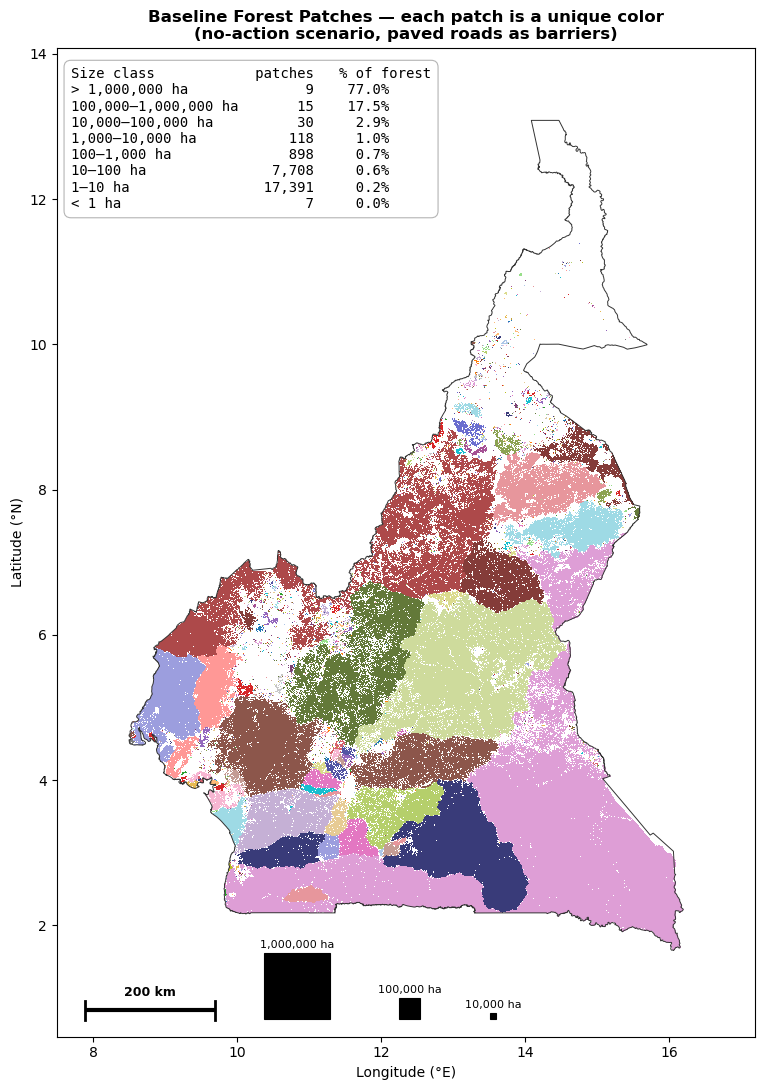

In [3]:
import math
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import tab20, tab20b

# ── Load patch-ID raster ──────────────────────────────────────────────────────
with rasterio.open(_BASELINE_TIF) as src:
    id_arr   = src.read(1)
    size_ext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# ── Assign a random color index (1–40) to each patch ─────────────────────────
N_COLORS   = 40
rng        = np.random.default_rng(42)
patch_ids  = np.unique(id_arr[id_arr > 0])
cidx_vals  = rng.integers(1, N_COLORS + 1, size=len(patch_ids)).astype(np.uint8)
id_to_cidx = np.zeros(int(patch_ids.max()) + 1, dtype=np.uint8)
id_to_cidx[patch_ids] = cidx_vals

STEP      = 3
cidx_disp = id_to_cidx[id_arr[::STEP, ::STEP]]

_qcols      = list(tab20.colors) + list(tab20b.colors)
cmap_unique = ListedColormap(["white"] + _qcols[:N_COLORS])
norm_unique = BoundaryNorm(np.arange(-0.5, N_COLORS + 1.5), ncolors=N_COLORS + 1)

map_xmin, map_xmax = size_ext[0], size_ext[1]
map_ymin, map_ymax = size_ext[2], size_ext[3]
map_w = map_xmax - map_xmin
map_h = map_ymax - map_ymin

# ── Layout constants ──────────────────────────────────────────────────────────
lat_c      = (map_ymin + map_ymax) / 2
km_per_deg = 111.32 * math.cos(math.radians(lat_c))

label_gap = map_h * 0.003
tick_h    = map_h * 0.010

# Anchor to the actual southern tip of Cameroon, not the raster extent
country_south = cmr0_wgs.total_bounds[1]
max_sq_deg    = math.sqrt(1_000_000 / 100) / km_per_deg
y_bottom      = country_south - max_sq_deg - label_gap
y_axis_min    = y_bottom - label_gap * 6

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 11))

ax.imshow(cidx_disp, cmap=cmap_unique, norm=norm_unique,
          extent=size_ext, origin="upper", interpolation="nearest", zorder=0)
cmr0_wgs.plot(ax=ax, color="none", edgecolor="#333333", linewidth=0.7, zorder=1)
ax.set_xlim(map_xmin, map_xmax)
ax.set_ylim(y_axis_min, map_ymax)
ax.set_title(
    "Baseline Forest Patches — each patch is a unique color\n"
    "(no-action scenario, paved roads as barriers)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

# ── Scale bar ─────────────────────────────────────────────────────────────────
scale_km  = 200
scale_deg = scale_km / km_per_deg
bar_h     = map_h * 0.018
x0 = map_xmin + map_w * 0.04
x1 = x0 + scale_deg
y_bar = y_bottom + bar_h / 2

ax.plot([x0, x1], [y_bar, y_bar], color="black", linewidth=3,
        solid_capstyle="butt", zorder=5)
for x in [x0, x1]:
    ax.plot([x, x], [y_bar - tick_h, y_bar + tick_h],
            color="black", linewidth=2, zorder=5)
ax.text((x0 + x1) / 2, y_bottom + bar_h + label_gap,
        f"{scale_km} km", ha="center", va="bottom",
        fontsize=9, fontweight="bold", zorder=5)

# ── Reference squares (bottom-aligned, largest → smallest, all black) ─────────
gap_between = map_w * 0.1
cursor_x    = x1 + map_w * 0.07

for sq_ha, sq_label in [
    (1_000_000, "1,000,000 ha"),
    (  100_000,   "100,000 ha"),
    (   10_000,    "10,000 ha"),
]:
    sq_km  = math.sqrt(sq_ha / 100)
    sq_deg = sq_km / km_per_deg

    ax.add_patch(plt.Rectangle(
        (cursor_x, y_bottom), sq_deg, sq_deg,
        facecolor="black", edgecolor="black", linewidth=0.8, zorder=5,
    ))
    ax.text(cursor_x + sq_deg / 2, y_bottom + sq_deg + label_gap,
            sq_label, ha="center", va="bottom", fontsize=8, zorder=5)

    cursor_x += sq_deg + gap_between

# ── Stats text box (top-left) ─────────────────────────────────────────────────
BIN_LABELS_LS = ["> 1,000,000 ha", "100,000–1,000,000 ha", "10,000–100,000 ha",
                 "1,000–10,000 ha", "100–1,000 ha", "10–100 ha", "1–10 ha", "< 1 ha"]

lines = ["Size class            patches   % of forest"]
for i, label in enumerate(BIN_LABELS_LS):
    row = size_df.iloc[i]
    lines.append(f"{label:<20s}  {int(row['Patch count']):>7,}   {row['% of forest area']:>5.1f}%")

ax.text(
    map_xmin + map_w * 0.02,
    map_ymax - map_h * 0.02,
    "\n".join(lines),
    va="top", ha="left", fontsize=10,
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.88,
              edgecolor="#aaaaaa", linewidth=0.8),
    zorder=6,
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_baseline_patch_size_map.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# size_df, patch_ha

## Admin2-level Forest Fragmentation Indicators

Spatial breakdown of fragmentation metrics by department (admin2), derived from
the baseline forest patch map (no-action scenario, paved roads as barriers).

Key indicators:
- **`pct_forest`** — share of department area classified as forest
- **`n_patches`** — number of distinct forest patches ≥ 1 ha
- **`frag_index`** — fragmentation index (lower = more fragmented relative to forest area)
- **`mean_patch_ha`** — average patch size; smaller values indicate more fragmentation

In [5]:
GPKG_FP = PATCH_DIR / "no_action__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.gpkg"

gdf = gpd.read_file(GPKG_FP).to_crs("EPSG:4326")

# Keep only columns needed for analysis
INDICATOR_COLS = ["adm2_name1", "adm1_name1", "area_ha", "forest_ha",
                  "pct_forest", "n_patches", "largest_patch_ha",
                  "mean_patch_ha", "frag_index", "geometry"]
gdf = gdf[INDICATOR_COLS].copy()
gdf = gdf.rename(columns={"adm2_name1": "department", "adm1_name1": "region"})

print(f"Admin2 units: {len(gdf)}")
ipy_display(
    gdf.drop(columns="geometry")
    .sort_values("n_patches", ascending=False)
    .head(10)
    .style
    .format({
        "area_ha":          "{:,.0f}",
        "forest_ha":        "{:,.0f}",
        "pct_forest":       "{:.1f}%",
        "n_patches":        "{:,}",
        "largest_patch_ha": "{:,.0f}",
        "mean_patch_ha":    "{:.1f}",
        "frag_index":       "{:.4f}",
    })
    .set_caption("Top 10 departments by patch count")
    .background_gradient(subset=["n_patches"], cmap="YlOrRd")
)

Admin2 units: 58


,department,region,area_ha,forest_ha,pct_forest,n_patches,largest_patch_ha,mean_patch_ha,frag_index
28,Mayo-Rey,Nord,"3,577,800","2,234,155",62.4%,"5,005","907,113",446.1,0.0022
1,Bénoué,Nord,"1,338,643","220,729",16.5%,"3,173","67,636",69.2,0.0144
10,Faro,Nord,"1,147,584","628,679",54.8%,"2,414","506,765",260.2,0.0038
49,Noun,Ouest,"743,591","360,252",48.5%,"1,122","215,441",321.0,0.0031
11,Faro-et-Déo,Adamaoua,"1,042,610","760,541",73.0%,"1,097","737,129",693.1,0.0014
56,Vina,Adamaoua,"1,670,439","1,216,096",72.8%,"1,078","485,070",1127.9,0.0009
24,Mayo-Banyo,Adamaoua,"826,059","497,472",60.2%,940,"216,007",529.1,0.0019
32,Mbam-et-Kim,Centre,"2,537,015","2,028,881",80.0%,929,"1,263,069",2183.7,0.0005
22,Lom-et-Djérem,Est,"2,535,214","2,077,557",82.0%,852,"1,545,529",2438.2,0.0004
27,Mayo-Louti,Nord,"412,430","22,868",5.5%,711,"3,488",31.8,0.0310


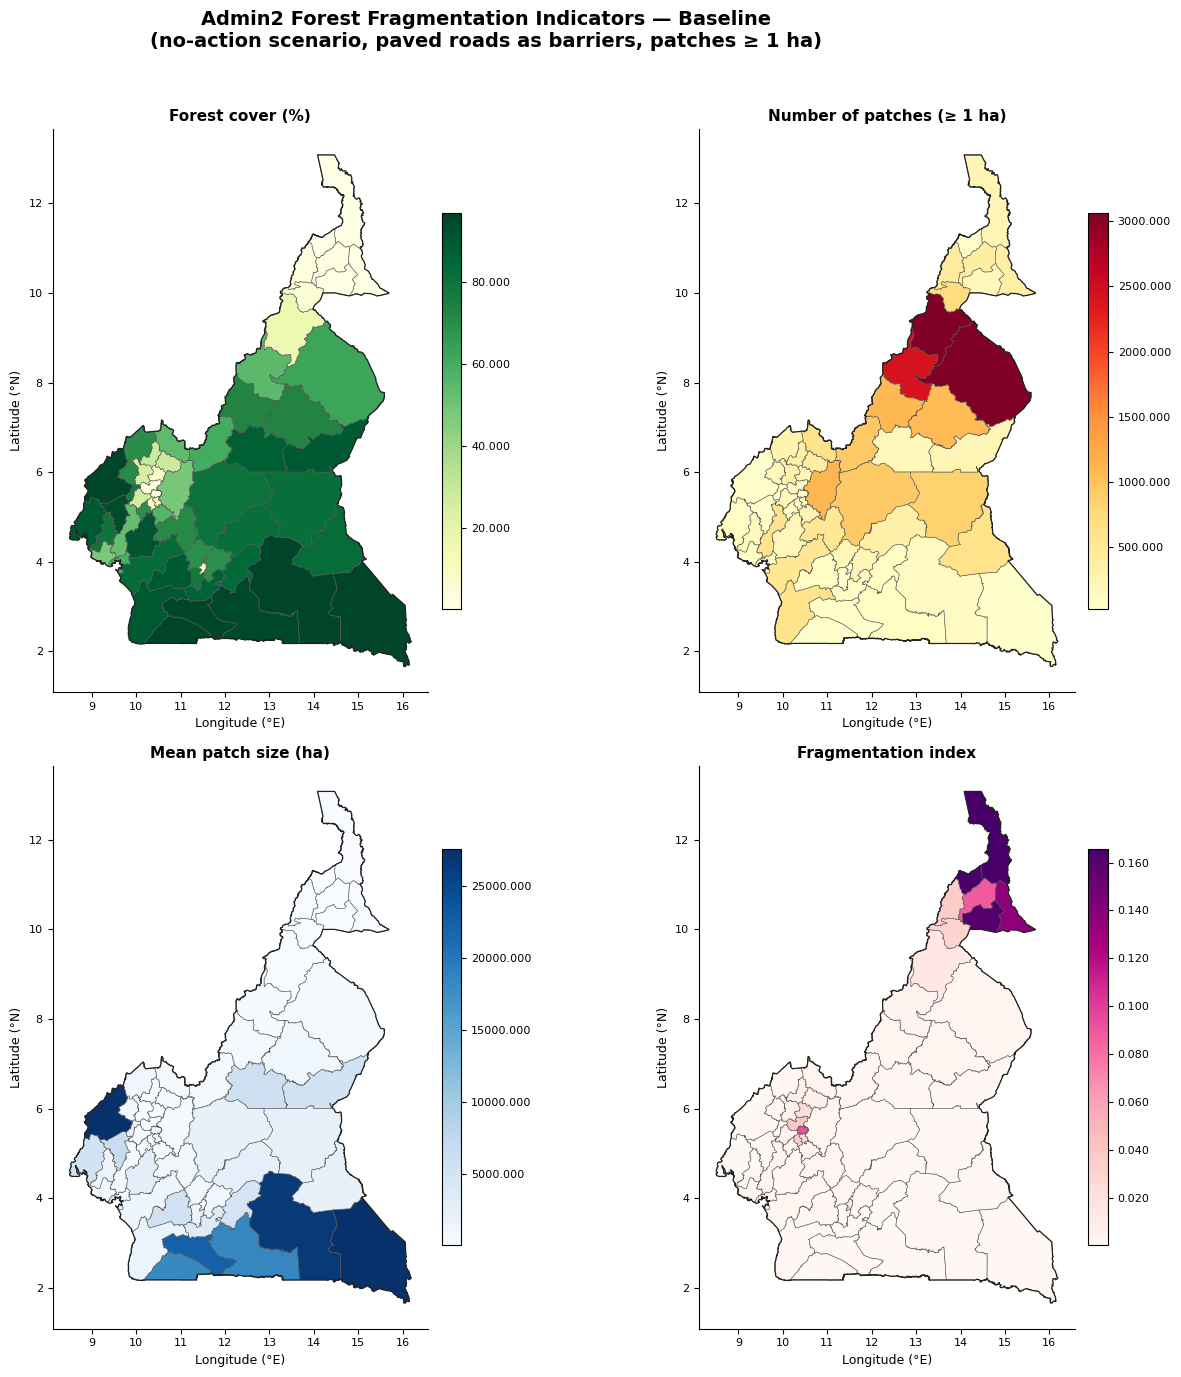

In [6]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker

PANEL_SPECS = [
    ("pct_forest",    "Forest cover (%)",           "YlGn",   "{:.0f}%",   False),
    ("n_patches",     "Number of patches (≥ 1 ha)", "YlOrRd", "{:,.0f}",   False),
    ("mean_patch_ha", "Mean patch size (ha)",        "Blues",  "{:,.0f}",   False),
    ("frag_index",    "Fragmentation index",         "RdPu",   "{:.3f}",    False),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle(
    "Admin2 Forest Fragmentation Indicators — Baseline\n"
    "(no-action scenario, paved roads as barriers, patches ≥ 1 ha)",
    fontsize=14, fontweight="bold", y=0.98,
)

for ax, (col, title, cmap_name, fmt, _) in zip(axes.flat, PANEL_SPECS):
    vmin = gdf[col].quantile(0.02)
    vmax = gdf[col].quantile(0.98)
    norm = Normalize(vmin=vmin, vmax=vmax)

    gdf.plot(
        column=col, ax=ax, cmap=cmap_name, norm=norm,
        edgecolor="#555555", linewidth=0.4, legend=False,
    )
    cmr0_wgs.plot(ax=ax, color="none", edgecolor="#222222", linewidth=0.9, zorder=2)

    sm = ScalarMappable(cmap=cmap_name, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, orientation="vertical")
    cb.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: fmt.format(x))
    )
    cb.ax.tick_params(labelsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Longitude (°E)", fontsize=9)
    ax.set_ylabel("Latitude (°N)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(RESULTS_DIR / "fig_admin2_fragmentation_choropleths.png", dpi=150, bbox_inches="tight")
plt.show()

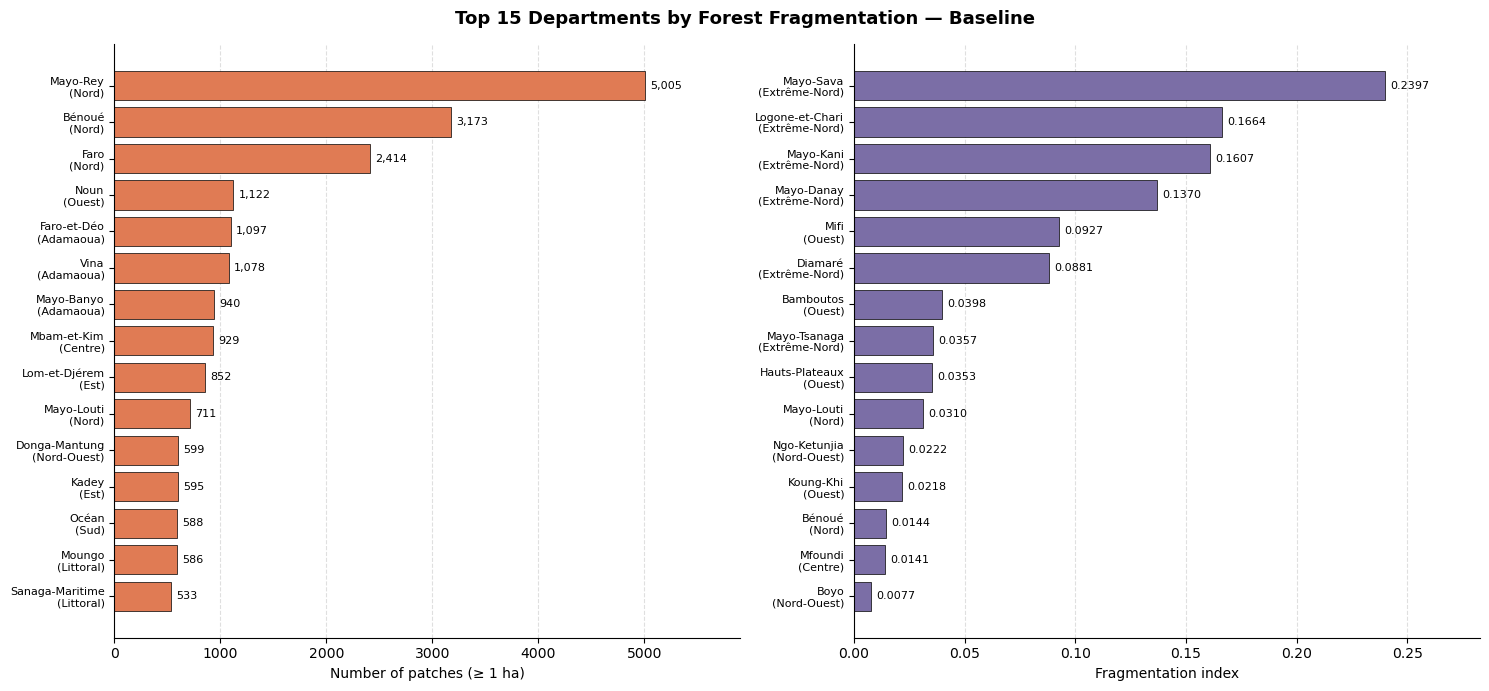

In [7]:
TOP_N = 15

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    f"Top {TOP_N} Departments by Forest Fragmentation — Baseline",
    fontsize=13, fontweight="bold",
)

BAR_SPECS = [
    ("n_patches",  "Number of patches (≥ 1 ha)", "#e07b54", "{:,.0f}"),
    ("frag_index", "Fragmentation index",          "#7b6ea6", "{:.4f}"),
]

for ax, (col, xlabel, color, fmt) in zip(axes, BAR_SPECS):
    top = gdf.nlargest(TOP_N, col)[["department", "region", col]].iloc[::-1]
    labels = [f"{d}\n({r})" for d, r in zip(top["department"], top["region"])]
    vals   = top[col].tolist()

    ax.barh(labels, vals, color=color, edgecolor="black", linewidth=0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, max(vals) * 1.18)
    for i, v in enumerate(vals):
        ax.text(v + max(vals) * 0.01, i, fmt.format(v), va="center", fontsize=8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_admin2_top_fragmented_depts.png", dpi=150, bbox_inches="tight")
plt.show()